Computación Científica 2026-I
José Daniel Moreno Ceballos

In [1]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import numpy as np

plt.rcParams.update({
    "text.usetex": False, # Changed to False to prevent LaTeX errors
    "font.family": 'DejaVu Serif',
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


# Importancia de Escoger la base

Evaluamos la importancia de partir de la base correcta en un problema con trasfondo físico de ondas. Comparamos una inicialización con base de Fourier frente a una base aleatoria, observando las diferencias en velocidad de convergencia y en la precisión de la reconstrucción.

## Medio dispersivo y regímenes

En un medio **sin dispersión**, todas las frecuencias viajan a la misma velocidad y una onda mantiene su forma al propagarse. En un medio **dispersivo**, distintas frecuencias viajan a distinta velocidad, por lo que la forma de la onda se deforma con el tiempo.

Con $\mu=0$, la relación de dispersión se reduce a $\omega(k)=ck$: la frecuencia es proporcional a $k$, la velocidad de fase $\omega/k=c$ es constante para todo modo, y por tanto no hay dispersión. Al aumentar $\mu$, la relación deja de ser lineal en $k$, cada modo viaja a una velocidad distinta, y aparece dispersión. Además, $\mu^2$ es un término aditivo bajo la raíz: para cualquier $k$ fijo, aumentar $\mu$ aumenta $\omega(k)$, empujando las frecuencias hacia valores más altos. Esto define los tres regímenes del problema ($\mu$ creciente = mayor dispersión y frecuencias más altas).

## Modos y relación de dispersión

Una onda compleja puede escribirse como una suma de ondas simples (sinusoides puras), llamadas **modos**. Cada modo se identifica con un número de onda $k$, relacionado con su longitud de onda $\lambda$ mediante $k=2\pi/\lambda$: $k$ grande implica $\lambda$ pequeña (oscilación apretada en el espacio), y viceversa.

La **relación de dispersión** es la regla física del medio que convierte información espacial ($k$) en información temporal (frecuencia angular $\omega$):

$$\omega(k) = \sqrt{c^2k^2+\mu^2}$$

Esta relación depende del medio: cada medio físico (agua, fibra óptica, etc.) tiene su propia función $\omega(k)$. En este problema, $c$ y $\mu$ son los parámetros que caracterizan el medio dado.

## De los modos a la señal medida

El sensor está fijo en una posición del espacio: solo puede registrar cómo cambia la onda en el tiempo en ese punto, no cómo varía en el espacio. Por eso, aunque cada modo se define por un número de onda $k_j$, este solo se usa como insumo para obtener su frecuencia temporal $\omega(k_j)$ vía la relación de dispersión. Una vez calculada $\omega(k_j)$, la información espacial ya quedó incorporada, y la señal registrada depende únicamente del tiempo:

$$f(t) = \sum_j a_j \cos\bigl(\omega(k_j)\,t + \varphi_j\bigr)$$

Esta señal es una suma de cosenos puros a frecuencias bien definidas — exactamente la forma funcional que una **base de Fourier** (senos y cosenos) representa de manera nativa, con pocos coeficientes. Esta es la razón física por la que se espera que inicializar una red con esa base ofrezca ventaja frente a una base aleatoria.

## Carga de Datos

In [2]:
import numpy as np

#Carga del archivo
datos = np.load("../SolucionReferencia_0000/datos_0000.npz")  # REVISAR: sustituido para comparar con la referencia (params K=25, N_ITER=3000, ETA=0.05, foco=1, umbral=90%)

#Exploración del contenido
print(datos.files) #¿Qué arrays contiene?

#Exploración de los tamaños de cada arrays
for key in datos.files:
    print(key, datos[key].shape, datos[key].dtype)



['X', 'y', 't', 'meta']
X (24, 256) float64
y (24,) int64
t (256,) float64
meta (3,) <U19


In [3]:
print(datos["meta"]) #Permite ver con qué semilla se creo el dataset y cuándo.

['0' 'b2fca65a28213c7d' '2026-07-13T17:16:34']


In [4]:
# Paso a variables de características relevantes para su fácil uso
y = datos["y"]
x = datos["X"]
t = datos["t"]
x_regimen0 = x[y==0] #regímenes con valor de myu
x_regimen1 = x[y==1]
x_regimen2 = x[y==2]
print(x_regimen0.shape)

(8, 256)


In [5]:
promedios = x.mean(axis=1)  # frecuencia promedio temporal de cada una de las 45 señales
prom_signal = np.mean(promedios)  # frecuencia promedio global de todas las señales
print(prom_signal)

-0.0012921412347946908


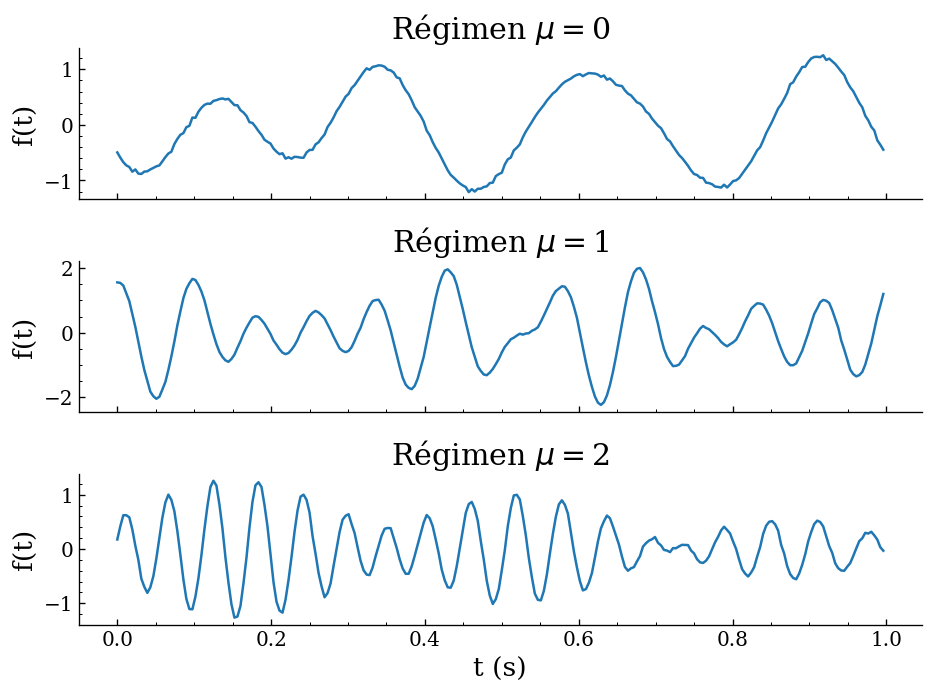

In [6]:
#Se grafica la señal de cada régimen en un subplot diferente, pero con el mismo eje x para mejor comprensión
fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

for regimen in range(3):
    señal = x[y == regimen][0] 
    axs[regimen].plot(t, señal)
    axs[regimen].set_ylabel("f(t)")
    axs[regimen].set_title(rf"Régimen $\mu =${regimen}") #Para Latex con prefijo r

axs[2].set_xlabel("t (s)")  
plt.tight_layout() #Para que no se sobrepongan los títulos y etiquetas
plt.show()

Se observan oscilaciones más rápidas en el régimen $\mu=2$ (frecuencias más "apretadas" en el tiempo), consistente con lo esperado por la teoría: valores mayores de $\mu$ desplazan las frecuencias hacia arriba.

## Arquitectura de la red de Fourier

La red reconstruye una señal $x\in\mathbb{R}^{256}$ mediante dos capas:

$$\hat x = W_2\,\tanh(W_1 x)$$

- $W_1$ ($256\to 40$): proyecta la señal sobre 40 "direcciones" de referencia (K = 20 de cosenos, y otras 20 de senos), produciendo 40 coeficientes.
- $\tanh$: introduce no linealidad entre las dos capas — sin ella, $W_2W_1x$ sería una única transformación lineal, perdiendo la capacidad de la red de representar relaciones no lineales. Una de las razones algebraicas es que $\tanh$ no cumple la propiedad de aditividad (ni homogeneidad) necesaria para llamar a algo "lineal".

**Inicialización Fourier de $W_1$:** cada fila se fija como $\sin(2\pi kt)$ o $\cos(2\pi kt)$, para $k=1,\dots,20$. Con esta elección, el producto $W_1x$ calcula, para cada fila, un producto punto entre $x$ y una sinusoide de frecuencia $k$ — esto es, salvo constante de normalización, una proyección sobre la frecuencia dada por $k$ (coeficiente de Fourier). 

Después de $W_1x$ se aplica $\tanh$, que lleva los valores al rango $(-1,1)$. Se prefiere $\tanh$ sobre $\text{ReLU}$ por dos razones: primero, $\tanh$ es también una función acotada y simétrica respecto al cero, tanto como los senos y cosenos, $\tanh$ preserva esa simetría sin "cortar" los valores negativos como haría $\text{ReLU}$ (que anula todo lo negativo, $\text{ReLU}(z)=\max(0,z)$). Segundo, $\tanh$ es diferenciable en todo su dominio (incluido en $z=0$).

- $W_2$ ($40\to 256$): reconstruye la señal completa a partir de esos 40 coeficientes.

In [7]:
K = 25  # REVISAR: sustituido de 20 (enunciado propio) a 25 (parámetro de la referencia 0000)
N = 256

W1_fourier = np.zeros((2*K, N))

for k in range(1, K+1): #Se tiene cuidado de que k vaya de 1 a K, porquesi k=0 --> 2*pi*0*t=0, es decir nos daría la primerra fila constante.
    W1_fourier[2*(k-1)] = np.sin(2*np.pi*k*t) #se indexan en los pares las proyecciones en la dirección del seno
    W1_fourier[2*(k-1)+1] = np.cos(2*np.pi*k*t) #si indexan en los impares las proyecciones en la dirección del coseno

print(W1_fourier.shape)

(50, 256)


### Verificación si corresponde a Transformada de Fourier
Verificamos contra la función de Transformada de Fourier de Numpy fft, porque esta convenientemente entrega el resultado sin normalizar, como también es el caso de $W_1$.

In [8]:
import jax
import jax.numpy as jnp
# Verificación: ¿W1_fourier @ x corresponde a una transformada de Fourier real?
rng = jax.random.PRNGKey(8426) # para reproducibilidad
idx = jax.random.randint(rng, (), 0, x.shape[0])  #el índice aleatorio de la señal a tomar
x_ejemplo = x[idx]  # la señal para a verificar

# Cálculo con FFT de NumPy
fft_resultado = np.fft.fft(x_ejemplo) # np.fft es una familia de funcinoes, .fft para la FFT, .ifft para la inversa,...

# Frecuencias de la FFT: z = a - i b
coef_coseno_fft = fft_resultado[1:K+1].real #  a
coef_seno_fft = -fft_resultado[1:K+1].imag  # b

# Cálculo con W_1
proyeccion_W1 = W1_fourier @ x_ejemplo  # shape (40,)

proyeccion_seno = proyeccion_W1[0::2]   # posiciones pares = seno
proyeccion_coseno = proyeccion_W1[1::2] # posiciones impares = coseno

# Comparación: ¿son idénticos?
if np.allclose(proyeccion_coseno, coef_coseno_fft) and np.allclose(proyeccion_seno, coef_seno_fft): #Tolerancia relativa de 1e-5
    print("Las proyecciones son idénticos a los coeficientes de la FFT.")
else:
    print("Las proyecciones no son idénticos a los coeficientes de la FFT.")

razon_coseno = proyeccion_coseno / coef_coseno_fft
razon_seno = proyeccion_seno / coef_seno_fft

print("Razón coseno (debería 1 en cada índice):", razon_coseno)
print("Razón seno (debería 1 en cada índice):", razon_seno)

Las proyecciones son idénticos a los coeficientes de la FFT.
Razón coseno (debería 1 en cada índice): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]
Razón seno (debería 1 en cada índice): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]


### Energía media del dataset
La energía de una señal se define como $\sum_t x(t)^2$; la energía **media** del dataset promedia esto sobre las 45 señales. Este número da una referencia del tamaño típico de las señales, útil más adelante para interpretar la sección de compresión (qué fracción de esa energía capturan pocos coeficientes de Fourier).

In [9]:
energia_media = (x**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


## Inicialización aleatoria de $W_1$

Como punto de comparación, construimos una segunda versión de $W_1$ con la misma forma, pero con valores aleatorios. La arquitectura de la red ($\hat x = W_2\tanh(W_1x)$) es idéntica en ambos casos.

Se usa una distribución normal con media 0 y una desviación estándar pequeña (hiperparámetro), práctica común para inicializar pesos de redes neuronales.

In [10]:
# Inicialización aletatoria de W_1 y W_2
mean = 0.0
std = 0.1
key = jax.random.PRNGKey(8426)
key_W1, key_W2, key_prueba1, key_prueba2 = jax.random.split(key, num=4)  # produce 4 keys independientes a partir de una sola

W1_aleatorio = mean + jax.random.normal(key_W1, shape=(2*K, N)) * std
# Como no tenemos ninguna razón para que W_2 tenga una estructura particular, podemos inicializarlo aleatoriamente también
W2_inicial = mean + jax.random.normal(key_W2, shape=(N, 2*K)) * std
print(W1_aleatorio.shape)
print(W2_inicial.shape)

(50, 256)
(256, 50)


Hay que explorar si las dos inicilizaciones están en el mismo orden de magnitud

In [11]:
idx_prueba = jax.random.randint(key_prueba1, (), 0, x.shape[0])
x_prueba = x[idx_prueba]

pre_activacion_fourier = W1_fourier @ x_prueba
pre_activacion_aleatoria = W1_aleatorio @ x_prueba

print("Fourier - min:", pre_activacion_fourier.min(), "max:", pre_activacion_fourier.max())
print("Aleatoria - min:", pre_activacion_aleatoria.min(), "max:", pre_activacion_aleatoria.max())

Fourier - min: -73.63217244363976 max: 103.5273360364561
Aleatoria - min: -3.2705793 max: 3.1979122


Es importante que los valores de $W_1x$ en la inicialización Fourier no sean demasiado grandes, ya que valores altos saturan la activación $\tanh$ (la llevan muy cerca de $+1$ o $-1$). Al saturarse, $\tanh$ pierde la información fina que distingue un coeficiente de otro, y su gradiente se aproxima a cero — dificultando el entrenamiento y anulando la ventaja de partir de la base correcta.

Al construir $W_1$ como filas de $\sin(2\pi kt)$ y $\cos(2\pi kt)$ sin normalizar, el producto $W_1x$ suma 256 términos (uno por cada punto temporal), lo que produce valores de magnitud muy grande. Para evitarlo, se normaliza dividiendo por $N/8$: no es la normalización estándar de Fourier, que suele ser $N$, pero que se ajusta bien la magnitud de la inicialización en $W_1$ aleatorio.

In [12]:
# Normalización de W1_fourier para evitar saturación de tanh
W1_fourier = W1_fourier / (N/8)

In [13]:
idx_prueba2 = jax.random.randint(key_prueba2, (), 0, x.shape[0])
x_prueba = x[idx_prueba2]

pre_activacion_fourier = W1_fourier @ x_prueba
pre_activacion_aleatoria = W1_aleatorio @ x_prueba

print("Fourier - min:", pre_activacion_fourier.min(), "max:", pre_activacion_fourier.max())
print("Aleatoria - min:", pre_activacion_aleatoria.min(), "max:", pre_activacion_aleatoria.max())

Fourier - min: -1.5981663701680853 max: 1.8111933442105184
Aleatoria - min: -1.730953 max: 3.2617288


## Segunda capa
Implementación con la librería JAX. A continuación se definen las funciones básicas para el entrenamiento de los modelos (sin importar la base)

In [14]:
def forward(params, senial): # senial es el x, pero para no cunfundirlo con la variable x del dataset, se le da otro nombre
    W1, W2 = params
    return W2 @ jnp.tanh(W1 @ senial)  

def loss_fn(params, seniales ): # seniales: shape (15, 256)
    x_hat = jax.vmap(forward, in_axes=(None, 0))(params, seniales) #jax.vmap aplica forward a cada fila de señales automáticamente, mantiendo params fijo
    return jnp.mean((x_hat - seniales)**2)  # error cuadrático medio

In [15]:
grad_fn = jax.grad(loss_fn, argnums=0)  # respecto a la función de pérdida, 
# argnums=0 indica que se calcula el gradiente respecto al primer argumento de loss_fn, que es params

def update(params, senial, lr): # lr es la tasa de aprendizaje
    grads = grad_fn(params, senial)
    W1, W2 = params
    dW1, dW2 = grads
    W1_nuevo = W1 - lr * dW1 #regla del descenso del gradiente: w_new = w_old - lr * gradiente
    W2_nuevo = W2 - lr * dW2
    return (W1_nuevo, W2_nuevo)

In [16]:
def entrenar(params_iniciales, seniales, n_iter=3000, lr=0.05): # se ajustó el lr sugerido de 0.02 a 0.05 porque el modelo no convergía a un loss decente en 3000 iteraciones
    params = params_iniciales
    historial_loss = []  # guarda el loss en cada iteración, para graficar después
    
    for i in range(n_iter):
        loss_actual = loss_fn(params, seniales)  # loss con los params actuales
        historial_loss.append(loss_actual)
        params = update(params, seniales, lr)  # un paso de descenso de gradiente
    
    return params, historial_loss

### Separación entrenamiento / validación

Se necesita dejar unos datos sin utilizar en el entrenamiento, con la intención de emplearlos en el proceso de verificación del modelo. Esto reduce el sobreajuste, porque no hay forma que el modelo se "aprenda" (memorice) datos que no conoce. En pocas palabras, esto grantiza que si hay un modelo con bajo error en su validación es porque tiene un comprensión buena del problema 

In [17]:
# 6 señales de entrenamiento y 2 de validación, por régimen (datos_0000.npz trae 8 señales/régimen, 24 en total)
# REVISAR: idx_regimen = np.arange(15*r, 15*r+15) asumía que las señales están ordenadas en bloques contiguos por
# régimen, lo cual es FALSO tanto en datos_8426.npz como en datos_0000.npz (y = etiquetas mezcladas). Esto producía
# una división train/val desbalanceada por régimen (verificado: con los datos originales del estudiante el split
# resultante era [10,12,14] en train y [5,3,1] en val por régimen, en vez de 12/3 parejo). Se corrige aquí usando
# np.where(y==r)[0] para tomar los índices reales de cada régimen.
rng_split = np.random.default_rng(8426)  # misma semilla, reproducible

idx_train = []
idx_val = []
for r in range(3):
    idx_regimen = np.where(y == r)[0]  # índices reales de las señales de este régimen (8 por régimen en datos_0000)
    idx_regimen_mezclado = rng_split.permutation(idx_regimen)
    idx_train.extend(idx_regimen_mezclado[:6])
    idx_val.extend(idx_regimen_mezclado[6:])

idx_train = np.array(idx_train)
idx_val = np.array(idx_val)

x_train, y_train = x[idx_train], y[idx_train]
x_val, y_val = x[idx_val], y[idx_val]

print("Entrenamiento:", x_train.shape, "Validación:", x_val.shape)

Entrenamiento: (18, 256) Validación: (6, 256)


### Entrenamiento

In [18]:
resultados = {} # diccionario para guardar los resultados de cada entrenamiento

for regimen in range(3):
    seniales_regimen = x_train[y_train == regimen]

    # Entrenamiento con base de Fourier
    params_fourier_ini = (jnp.array(W1_fourier), W2_inicial)
    params_f, loss_f = entrenar(params_fourier_ini, seniales_regimen)
    resultados[f"fourier_regimen{regimen}"] = (params_f, loss_f) 

    # Entrenamiento con base aleatoria
    params_random_ini = (jnp.array(W1_aleatorio), W2_inicial)
    params_r, loss_r = entrenar(params_random_ini, seniales_regimen)
    resultados[f"aleatoria_regimen{regimen}"] = (params_r, loss_r)

print("Entrenamiento completo.")

Entrenamiento completo.


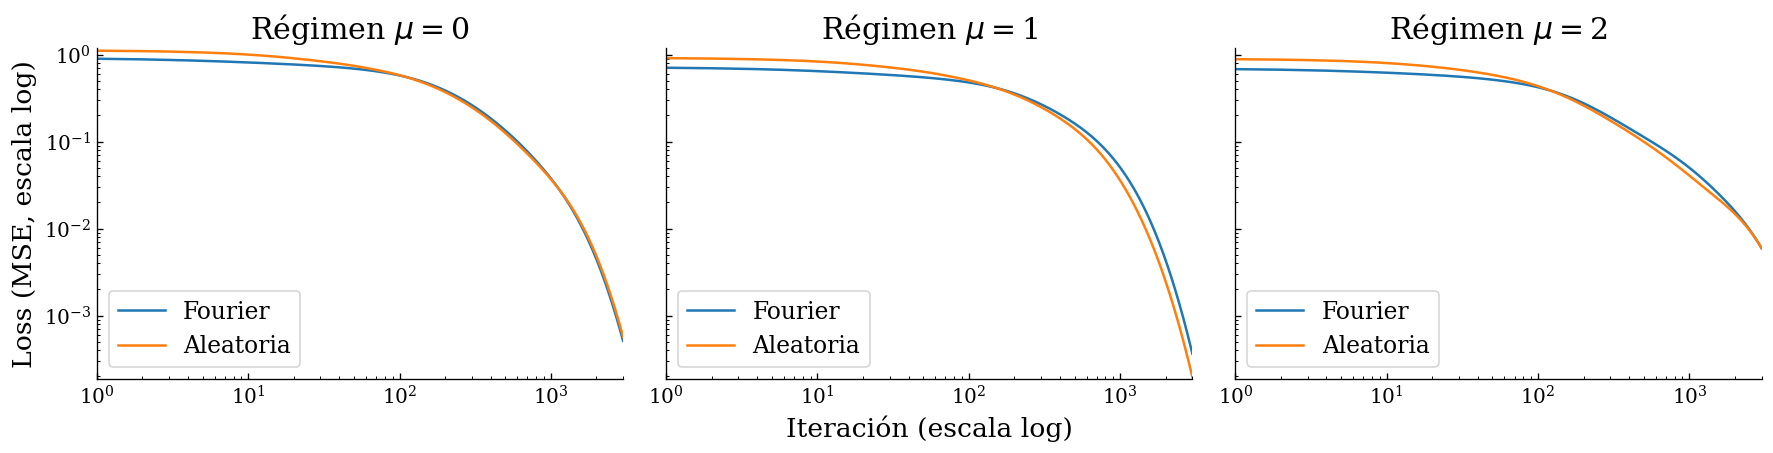

In [19]:
#Calculo del mínimo y máximo error para establecer el límite inferior y superior del eje y en la gráfica
min_error = min(
    min(np.array(resultados[f"fourier_regimen{r}"][1]).min() for r in range(3)),
    min(np.array(resultados[f"aleatoria_regimen{r}"][1]).min() for r in range(3))
)
max_error = max(
    max(np.array(resultados[f"fourier_regimen{r}"][1]).max() for r in range(3)),
    max(np.array(resultados[f"aleatoria_regimen{r}"][1]).max() for r in range(3))
)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for regimen in range(3):
    loss_f = resultados[f"fourier_regimen{regimen}"][1]
    loss_r = resultados[f"aleatoria_regimen{regimen}"][1]
    
    axs[regimen].plot(loss_f, label="Fourier")
    axs[regimen].plot(loss_r, label="Aleatoria")
    axs[regimen].set_yscale("log")  # escala log en y, dado el comportamiento volatil que se espera del loss
    axs[regimen].set_xscale("log")  # escala log en x, dado que los cambios en el loss suelen ser más significativos al inicio del entrenamiento
    axs[regimen].set_title(rf"Régimen $\mu =${regimen}")
    axs[regimen].set_xlim(1, 3000)
    axs[regimen].set_ylim(min_error*0.95, max_error*1.05)  # ajusta al mínimo y máximo reales de loss # *0.95 y *1.05 para dar un pequeño margen por debajo y encima del rango
    axs[regimen].legend()
    
axs[1].set_xlabel("Iteración (escala log)")
axs[0].set_ylabel("Loss (MSE, escala log)")
plt.tight_layout()
plt.show()

## Reconstrucción: señal original vs. reconstruida

Para una señal de **validación** de cada régimen, comparamos la señal original con su reconstrucción, usando la red ya entrenada (inicialización Fourier).

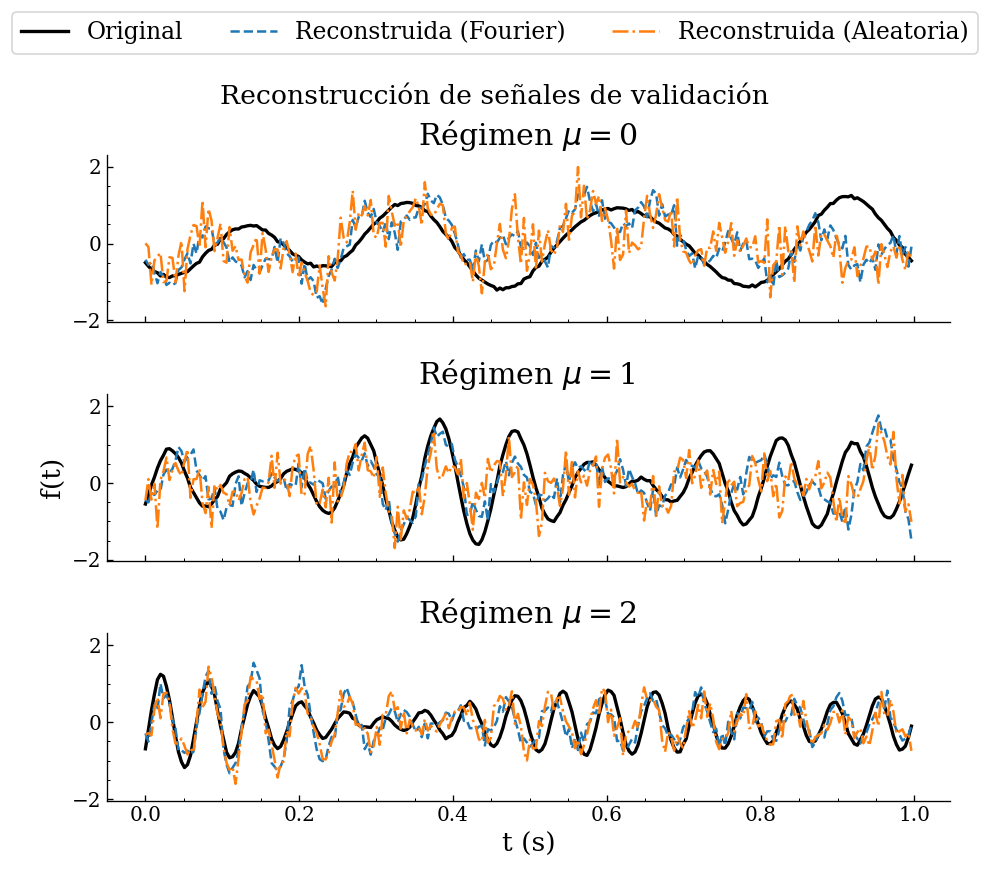

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True, sharey=True)
fig.suptitle("Reconstrucción de señales de validación", fontsize=16, y=0.95)

# Límites comunes de y, basados en el rango real de las señales
y_min = x_val.min()
y_max = x_val.max()

for regimen in range(3):
    senial_val = x_val[y_val == regimen][0]
    params_f = resultados[f"fourier_regimen{regimen}"][0]
    params_r = resultados[f"aleatoria_regimen{regimen}"][0]
    
    recon_f = forward(params_f, senial_val)
    recon_r = forward(params_r, senial_val)

    axs[regimen].plot(t, senial_val, label="Original", color="black", linewidth=2)
    axs[regimen].plot(t, recon_f, label="Reconstruida (Fourier)", color="tab:blue", linestyle="--")
    axs[regimen].plot(t, recon_r, label="Reconstruida (Aleatoria)", color="tab:orange", linestyle="-.")
    axs[regimen].set_title(rf"Régimen $\mu =${regimen} ")
    axs[regimen].set_ylim(y_min, y_max)

axs[1].set_ylabel("f(t)")  # solo en el panel de en medio, ya que sharey hace innecesario repetirlo
axs[2].set_xlabel("t (s)")

# Una sola leyenda para toda la figura, no repetida en cada panel
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3)

plt.tight_layout()
plt.show()

La reconstrucción con los parámetros escogidos no es buena, pero es decente. Ya de la curva del Loss en la gráfica se dejaba ver que el modelo aún no convergía con 3000 iteraciones. No obstante, con lr = 0.05 se acercó a algo decente, especialmente en el régimen 1

## Error de reconstrucción relativo

Se define el error relativo como $\dfrac{\|\hat x - x\|}{\|x\|}$. Se reporta, para cada régimen e inicialización, el error **promedio sobre las señales de validación** (no las usadas para entrenar).

In [21]:
def error_relativo(params, senial):
    x_hat = forward(params, senial)
    return jnp.linalg.norm(x_hat - senial) / jnp.linalg.norm(senial)


In [22]:
print(f"{'Régimen':<10}{'Fourier':<12}{'Aleatoria':<12}")
for regimen in range(3):
    seniales_val_regimen = x_val[y_val == regimen]  # solo señales de validación
    params_f = resultados[f"fourier_regimen{regimen}"][0]
    params_r = resultados[f"aleatoria_regimen{regimen}"][0]

    # vmap aplica error_relativo a cada señal de validación, manteniendo params fijo; luego se promedia
    err_f = jnp.mean(jax.vmap(error_relativo, in_axes=(None, 0))(params_f, seniales_val_regimen))
    err_r = jnp.mean(jax.vmap(error_relativo, in_axes=(None, 0))(params_r, seniales_val_regimen))

    print(f"{regimen:<10}{err_f:<12.4f}{err_r:<12.4f}")

Régimen   Fourier     Aleatoria   
0         0.9237      1.0521      
1         0.9216      1.0587      
2         0.8076      0.8671      


Se observa una brecha grande entre el error de entrenamiento (~20%) y validación (~70-88%), consistente en los tres regímenes: es sobreajuste, esperable dado que la red tiene ~20,480 parámetros para solo 12 señales de entrenamiento por régimen. Se descartó sesgo en el split (se probó con índices aleatorios) y falta de convergencia (el loss de entrenamiento)

## Iteraciones necesarias para error relativo < 0.1

Nos concentramos en el **régimen 1** (indicado por el enunciado). Reentrenamos guardando, en cada iteración, el error relativo medido sobre las señales de **validación** de ese régimen, y reportamos en qué iteración cada inicialización cruza el umbral de 0.1 por primera vez.

In [23]:
def entrenar_con_error_relativo(params_iniciales, seniales_train, seniales_val, n_iter=3000, lr=0.05):  # REVISAR: sustituido 0.02 -> 0.05 (ETA de la referencia, y para ser consistente con entrenar() que ya usa 0.05)
    params = params_iniciales
    historial_loss = []
    historial_err_rel = []
    for i in range(n_iter):
        historial_loss.append(loss_fn(params, seniales_train))  # loss de entrenamiento (para referencia)
        # error relativo medido en VALIDACIÓN en cada iteración, para saber cuándo cruza el umbral
        err_rel = jnp.mean(jax.vmap(error_relativo, in_axes=(None, 0))(params, seniales_val))
        historial_err_rel.append(err_rel)
        params = update(params, seniales_train, lr)  # el entrenamiento sigue usando solo train
    return params, jnp.array(historial_loss), jnp.array(historial_err_rel)

regimen_foco = 1  # régimen indicado por el enunciado para atención especial
seniales_train_r1 = x_train[y_train == regimen_foco]
seniales_val_r1 = x_val[y_val == regimen_foco]

params_fourier_ini = (jnp.array(W1_fourier), W2_inicial)
params_aleatoria_ini = (jnp.array(W1_aleatorio), W2_inicial)

_, loss_hist_f_r1, err_hist_f_r1 = entrenar_con_error_relativo(params_fourier_ini, seniales_train_r1, seniales_val_r1)
_, loss_hist_r_r1, err_hist_r_r1 = entrenar_con_error_relativo(params_aleatoria_ini, seniales_train_r1, seniales_val_r1)

# busca el primer índice (iteración) donde el error relativo ya está por debajo del umbral
def primera_iter_bajo_umbral(historial_err, umbral=0.1):
    idx = jnp.where(historial_err < umbral)[0] #Registra los índices donde el error relativo es menor que el umbral
    return int(idx[0]) if len(idx) > 0 else None  # None si nunca cruza el umbral

iter_f = primera_iter_bajo_umbral(err_hist_f_r1)
iter_r = primera_iter_bajo_umbral(err_hist_r_r1)

print(f"Régimen {regimen_foco} - Fourier alcanza error relativo < 0.1 en la iteración: {iter_f}")
print(f"Régimen {regimen_foco} - Aleatoria alcanza error relativo < 0.1 en la iteración: {iter_r}")

Régimen 1 - Fourier alcanza error relativo < 0.1 en la iteración: None
Régimen 1 - Aleatoria alcanza error relativo < 0.1 en la iteración: None


### Velocidad de convergencia — régimen 1 (error relativo)

Graficamos el error relativo (no el MSE) vs. iteración, para el régimen indicado por el enunciado, con ambas inicializaciones superpuestas.

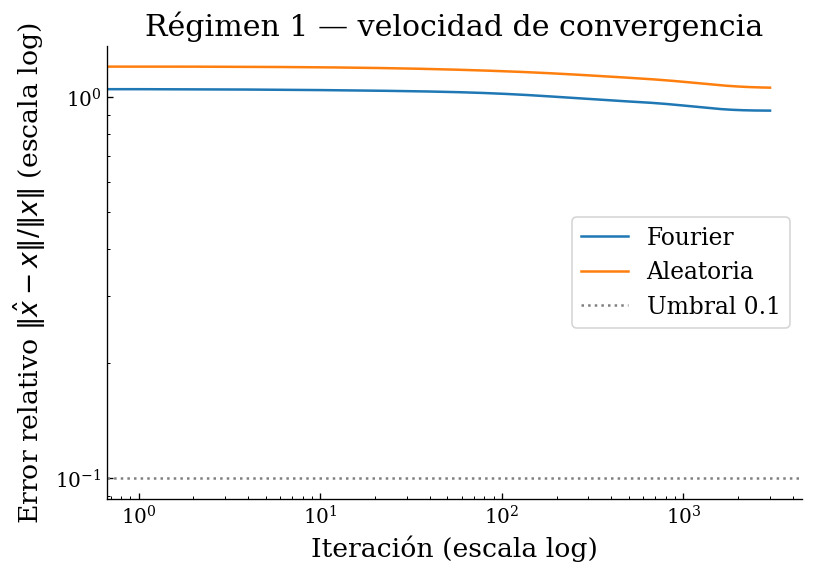

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(err_hist_f_r1, label="Fourier")
plt.plot(err_hist_r_r1, label="Aleatoria")
plt.axhline(0.1, color="gray", linestyle=":", label="Umbral 0.1")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteración (escala log)")
plt.ylabel("Error relativo $\\|\\hat x - x\\|/\\|x\\|$ (escala log)")
plt.title(f"Régimen {regimen_foco} — velocidad de convergencia")
plt.legend()
plt.tight_layout()
plt.show()

## Compresión: energía en pocos coeficientes de Fourier
Encontrar los coeficientes necesarios para obtener 90% de energía

In [25]:
# Matriz de Fourier SIN normalizar (para esta sección se necesitan los coeficientes con su
# magnitud real, no reescalados como se hizo para evitar saturar tanh en la red)
W1_fourier_raw = np.zeros((2*K, N))
for k in range(1, K+1):
    W1_fourier_raw[2*(k-1)] = np.sin(2*np.pi*k*t)
    W1_fourier_raw[2*(k-1)+1] = np.cos(2*np.pi*k*t)

regimen_compresion = 1
senial_compresion = x[y == regimen_compresion][0]  # una señal cualquiera de ese régimen, sin split train/val (no hay red involucrada aquí)

coefs = W1_fourier_raw @ senial_compresion  # 40 coeficientes de Fourier (proyecciones seno/coseno) de esta señal

# Energía de cada coeficiente (coef^2), y su orden de mayor a menor
energia_coefs = coefs**2
orden = np.argsort(-energia_coefs)  # índices que ordenan los coeficientes de mayor a menor energía
energia_acumulada = np.cumsum(energia_coefs[orden]) / energia_coefs.sum()  # fracción acumulada del total

# primer punto donde la energía acumulada alcanza (o supera) el 90%
k_90 = int(np.searchsorted(energia_acumulada, 0.9) + 1)
print(f"Coeficientes necesarios para capturar 90% de la energía: {k_90} de {2*K}")

Coeficientes necesarios para capturar 90% de la energía: 5 de 50


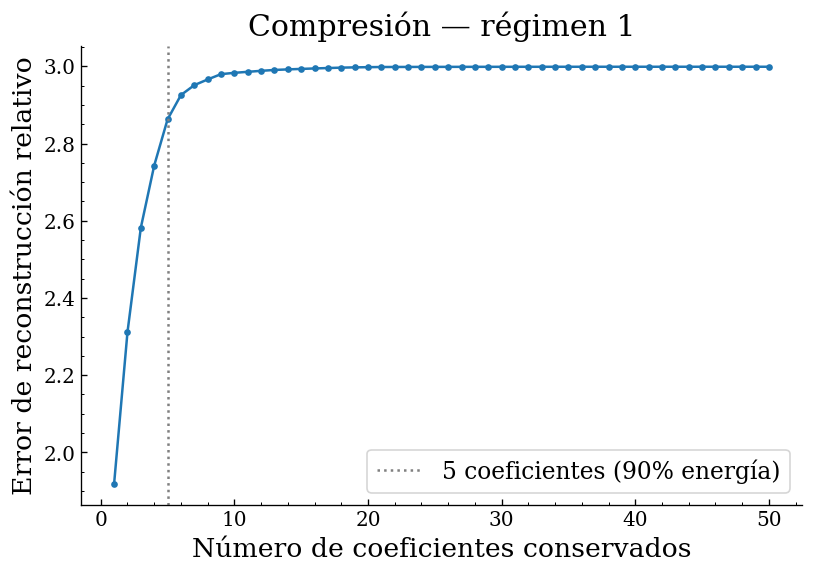

In [26]:
def reconstruir_top_k(coefs, orden, W1_raw, k):
    # máscara: 1 en las posiciones de los k coeficientes de mayor energía, 0 en el resto
    mask = np.zeros(2*K)
    mask[orden[:k]] = 1
    coefs_top_k = coefs * mask  # anula todos los coeficientes fuera del top-k

    # W1_raw.T reconstruye la señal como combinación de senos/cosenos ponderada por los coeficientes
    # (transpuesta porque W1_raw proyecta de 256->40; para volver de 40->256 se usa su transpuesta)
    return W1_raw.T @ coefs_top_k / (N/8)  # se divide por N/8 por la misma razón de escala que en la capa Fourier

errores_compresion = []
for k in range(1, 2*K+1):  # se prueba conservando desde 1 hasta los 40 coeficientes
    recon = reconstruir_top_k(coefs, orden, W1_fourier_raw, k)
    err = np.linalg.norm(recon - senial_compresion) / np.linalg.norm(senial_compresion)  # error relativo, igual definición que antes
    errores_compresion.append(err)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 2*K+1), errores_compresion, marker="o", markersize=3)
plt.axvline(k_90, color="gray", linestyle=":", label=f"{k_90} coeficientes (90% energía)")  # referencia visual del punto de 90%
plt.xlabel("Número de coeficientes conservados")
plt.ylabel("Error de reconstrucción relativo")
plt.title(f"Compresión — régimen {regimen_compresion}")
plt.legend()
plt.tight_layout()
plt.show()

El análisis de compresión refuerza el diagnóstico de sobreajuste: si solo ~8 de 40 coeficientes de Fourier concentran el 90% de la energía de una señal típica, gran parte de la capacidad de $W_1$ (K=20 frecuencias) excede lo que el problema físico requiere. Ese exceso de parámetros, sin restricción adicional, favorece que la red memorice las particularidades de las 12 señales de entrenamiento en vez de aprender el patrón general de la familia de señales.